# Нахождение корней уравнений

In [24]:
import sys

sys.path.append('..')

### 1. Метод последовательного поиска

##### Пример:

$$x^4 + 0.9x^3 - 2.3x^2 + 3.6x - 25.2 = 0$$

$$x^4 = - 0.9x^3 + 2.3x^2 - 3.6x + 25.2$$

Нарисуем графики функции:

$$y = x^4$$

и 

$$z = - 0.9x^3 + 2.3x^2 - 3.6x + 25.2$$

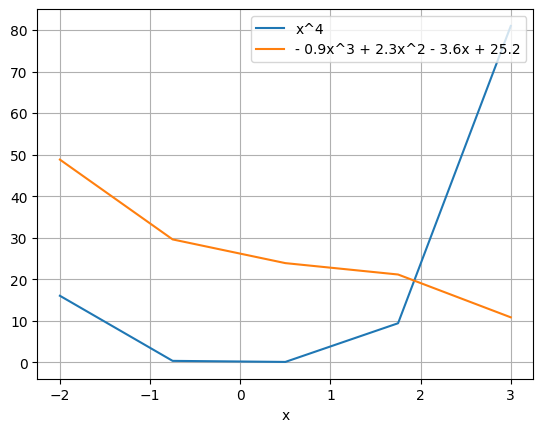

In [25]:
import numpy as np
from matplotlib import pyplot as plt

x = np.linspace(-2, 3, 5)

y = x**4
z = - 0.9*x**3 + 2.3*x**2 - 3.6*x + 25.2

plt.xlabel('x')
plt.grid(True)
plt.plot(x, y, label='x^4')
plt.plot(x, z, label='- 0.9x^3 + 2.3x^2 - 3.6x + 25.2')
plt.legend(loc='upper right')
plt.show()

Пусть:

$$f(x) = x^4 + 0.9x^3 - 2.3x^2 + 3.6x - 25.2$$

In [26]:
import numpy as np
from math import pow
from modules.equations.single import root_search

def f(x): return x**4 + 0.9*x**3 - 2.3*x**2 + 3.6*x - 25.2

x1, x2 = root_search(f, -2, 3, 0.001)

x1, x2

(2.0999999999997705, 2.1009999999997704)

In [27]:
f(x1), f(x2)

(-9.841016890277388e-12, 0.04292083929114199)

### 2. Метод бисекции

In [28]:
from modules.equations.single import bisection

x = bisection(f, -2, 3, 10**-9)

x

2.0999999997438863

In [29]:
f(x)

-1.0984969378569076e-08

### 3. Метод Риддера

In [30]:
from modules.equations.single import ridder

x, iter = ridder(f, -2, 3, 10**-9, 100)

x, iter

(2.0999999999999996, 7)

In [31]:
f(x)

-1.4210854715202004e-14

### 4. Метод Ньютона-Рафсона

$$f'(x) = 4x^3 + 2.7x^2 - 4.6x + 3.6$$

In [32]:
from modules.equations.single import newton_raphson

def df(x: float): return x**4 + 0.9*x**3 - 2.3*x**2 + 3.6*x - 25.2

x, iter = newton_raphson(f, df, -2, 3, 10**-9, 100)

x, iter

(2.100000000325963, 31)

In [33]:
f(x)

1.398088045334589e-08

### 5. Метод Ньютона-Рафсона для системы уравнении

##### Пример:

$$y - (x - 1)^2 = 0$$

$$(x + 1)^2 + (y-3)^2 - 5 = 0$$

In [34]:
import numpy as np
from math import sin, log
from modules.equations.system import newton_raphson_system

def f(x: np.ndarray[np.double]) -> np.ndarray[np.double]:
    fx = np.zeros(len(x))

    fx[0] = x[1] - x[0]**2 + 2*x[0] - 1.
    fx[1] = x[0]**2 + 2*x[0] + 1 + x[1]**2 - 6*x[1] + 9 - 5.

    return fx

x = np.array([1., 1.])

x, iter = newton_raphson_system(f, x, 2, 3, 10**-9)

x, iter

(array([-1.5, -5. ]), 1)

In [35]:
f(x)

array([-11.25,  59.25])